# FacetGrid Analysis

## Overview
**FacetGrid** creates a grid of subplots to compare distributions and relationships **across categorical subgroups**. It automatically handles splitting your data and creating simultaneous visualizations.

## When to Use FacetGrid
- ✅ Compare patterns across different groups
- ✅ Explore how relationships change by category
- ✅ Create publication-ready multi-panel figures
- ✅ Reduce overplotting in complex datasets

## Key Parameters
- `col/row`: Create subplots by these categorical variables
- `hue`: Color-code by another categorical variable (within each subplot)
- `col_wrap`: Wrap columns after N subplots (useful for many categories)
- `height/aspect`: Control subplot size and shape

In [ ]:
# Import Required Libraries
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Set professional plotting style
sns.set_theme(style="whitegrid", font_scale=0.95)
plt.rcParams['figure.dpi'] = 100
sns.set_palette("deep")

In [ ]:
# Load and explore the tips dataset
tips_df = sns.load_dataset("tips")
print(f"Dataset shape: {tips_df.shape}")
print(f"\nColumns: {tips_df.columns.tolist()}")
print(f"\nFirst few rows:")
tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Example 1: FacetGrid with Histogram
**Goal**: Compare bill distributions across time (Lunch/Dinner) and smoking status (Yes/No)

**Interpretation**:
- `col="time"` creates 2 columns (Lunch, Dinner)
- `row="smoker"` creates 2 rows (Yes, No)
- Total of 4 subplots, each showing distribution of total_bill
- Helps spot if spending patterns differ by these factors

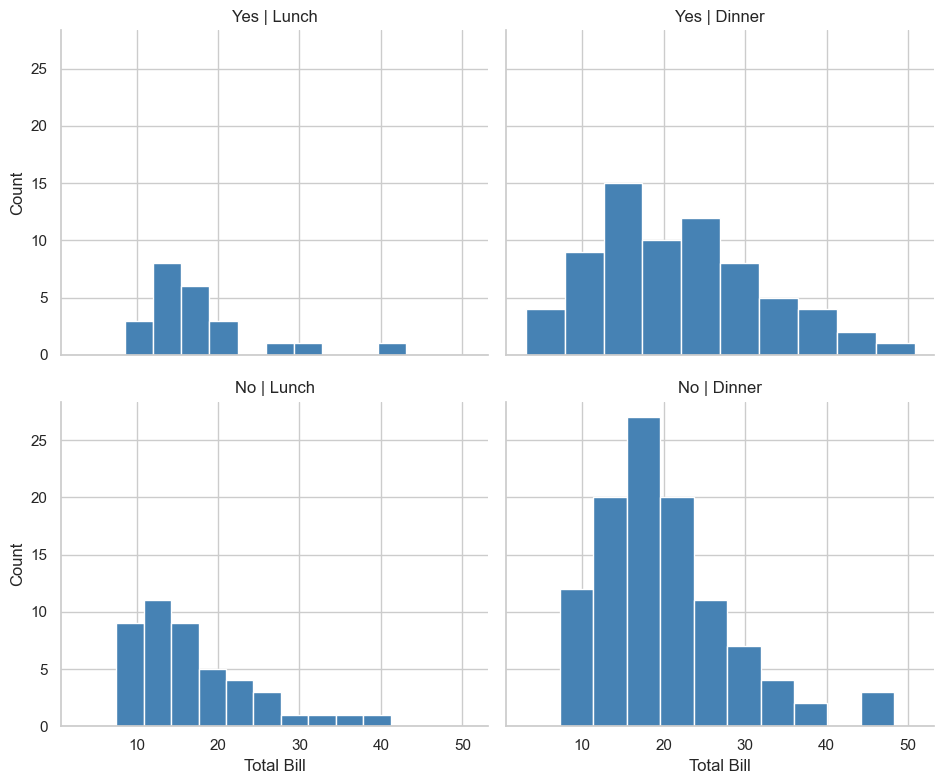

In [ ]:
# Create FacetGrid with histograms: 2 rows x 2 columns
tips_fg = sns.FacetGrid(
    tips_df, 
    col="time",           # Dinner / Lunch (columns)
    row="smoker",         # Yes / No (rows)
    height=4, 
    aspect=1.2
)

# Map histogram to each subplot
tips_fg.map(
    plt.hist, 
    "total_bill", 
    bins=12, 
    color="steelblue", 
    edgecolor="white",
    alpha=0.8
)

tips_fg.set_axis_labels("Total Bill ($)", "Count")
tips_fg.set_titles(col_template="Time: {col_name}", row_template="Smoker: {row_name}")
plt.suptitle("Distribution of Bills by Time & Smoking Status", fontsize=13, y=1.00, fontweight='bold')
plt.tight_layout()
plt.show()

## Example 2: FacetGrid with Scatter + Hue
**Goal**: Show relationship between bill and tip, separated by time, with smoking status color-coded

**Interpretation**:
- `col="time"` creates 2 subplots (Lunch vs Dinner)
- `hue="smoker"` uses color to distinguish smokers vs non-smokers within each subplot
- Scatter points show the correlation between total_bill and tip
- Lets us see if patterns differ by time AND smoking status

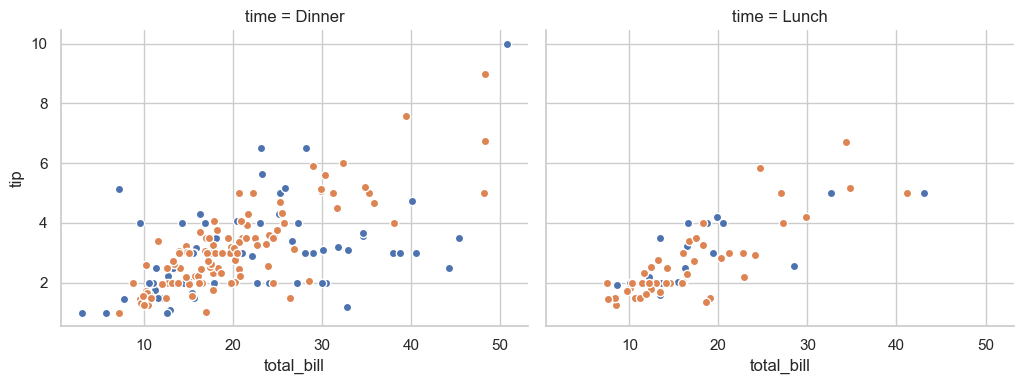

In [ ]:
# FacetGrid with scatter plot and hue distinction
tips_fg = sns.FacetGrid(
    tips_df, 
    col="time", 
    hue="smoker", 
    height=4, 
    aspect=1.3,
    col_order=['Dinner', 'Lunch']
)

tips_fg.map(
    plt.scatter, 
    "total_bill", 
    "tip",
    s=100,
    alpha=0.6,
    edgecolor='white',
    linewidth=0.5
)

tips_fg.add_legend(title="Smoker", loc='upper left')
tips_fg.set_axis_labels("Total Bill ($)", "Tip ($)")
plt.suptitle("Tip vs Bill: Effect of Time & Smoking Status", fontsize=13, y=1.00, fontweight='bold')
plt.tight_layout()
plt.show()

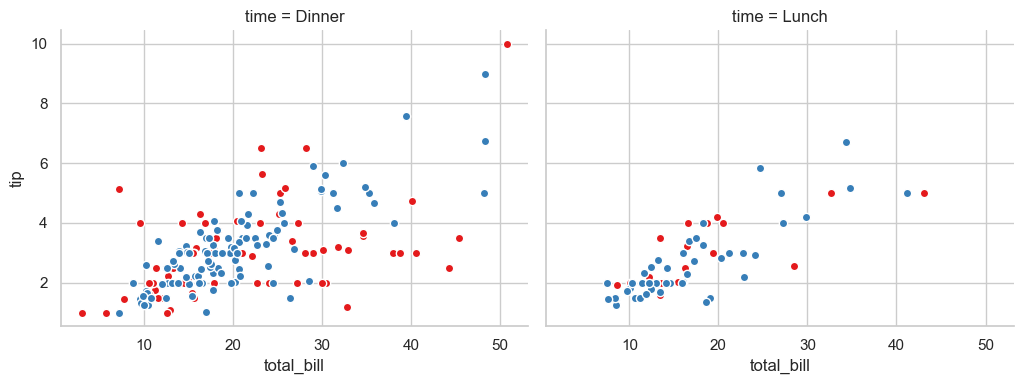

In [ ]:
# Same as Example 2, but with custom color palette
tips_fg = sns.FacetGrid(
    tips_df, 
    col="time", 
    hue="smoker", 
    height=4, 
    aspect=1.3,
    col_order=['Dinner', 'Lunch'], 
    palette="Set1"  # Custom color palette
)

tips_fg.map(
    plt.scatter, 
    "total_bill", 
    "tip",
    s=100,
    alpha=0.6,
    edgecolor='white',
    linewidth=0.5
)

tips_fg.add_legend(title="Smoker")
tips_fg.set_axis_labels("Total Bill ($)", "Tip ($)")
plt.tight_layout()
plt.show()

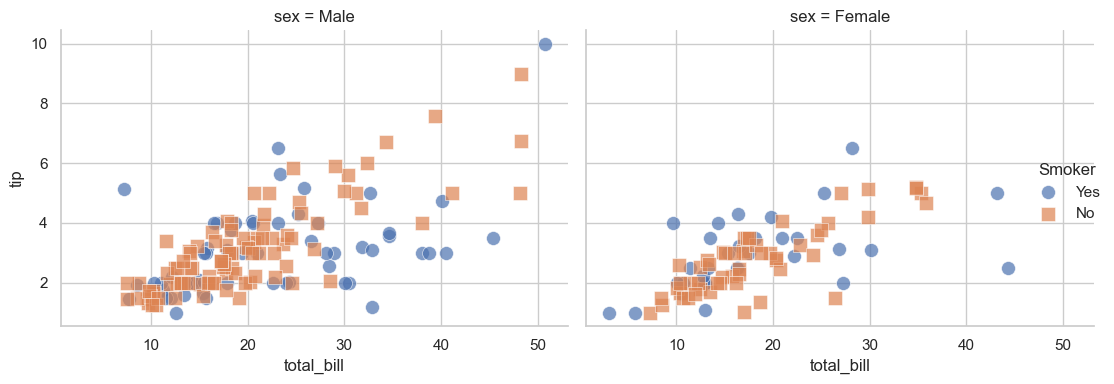

In [ ]:
# Advanced FacetGrid with custom styling
tips_fg = sns.FacetGrid(
    tips_df, 
    col="sex", 
    hue="smoker", 
    height=4, 
    aspect=1.3,
    hue_order=["Yes", "No"],
    hue_kws=dict(marker=["o", "s"])  # Different markers for hue groups
)

tips_fg.map(
    plt.scatter, 
    "total_bill", 
    "tip", 
    s=100, 
    linewidth=0.5, 
    edgecolor="white", 
    alpha=0.7
)

tips_fg.add_legend(title="Smoker")
tips_fg.set_axis_labels("Total Bill ($)", "Tip ($)")
plt.suptitle("Tip Patterns by Gender & Smoking Status", fontsize=13, y=1.00, fontweight='bold')
plt.tight_layout()
plt.show()

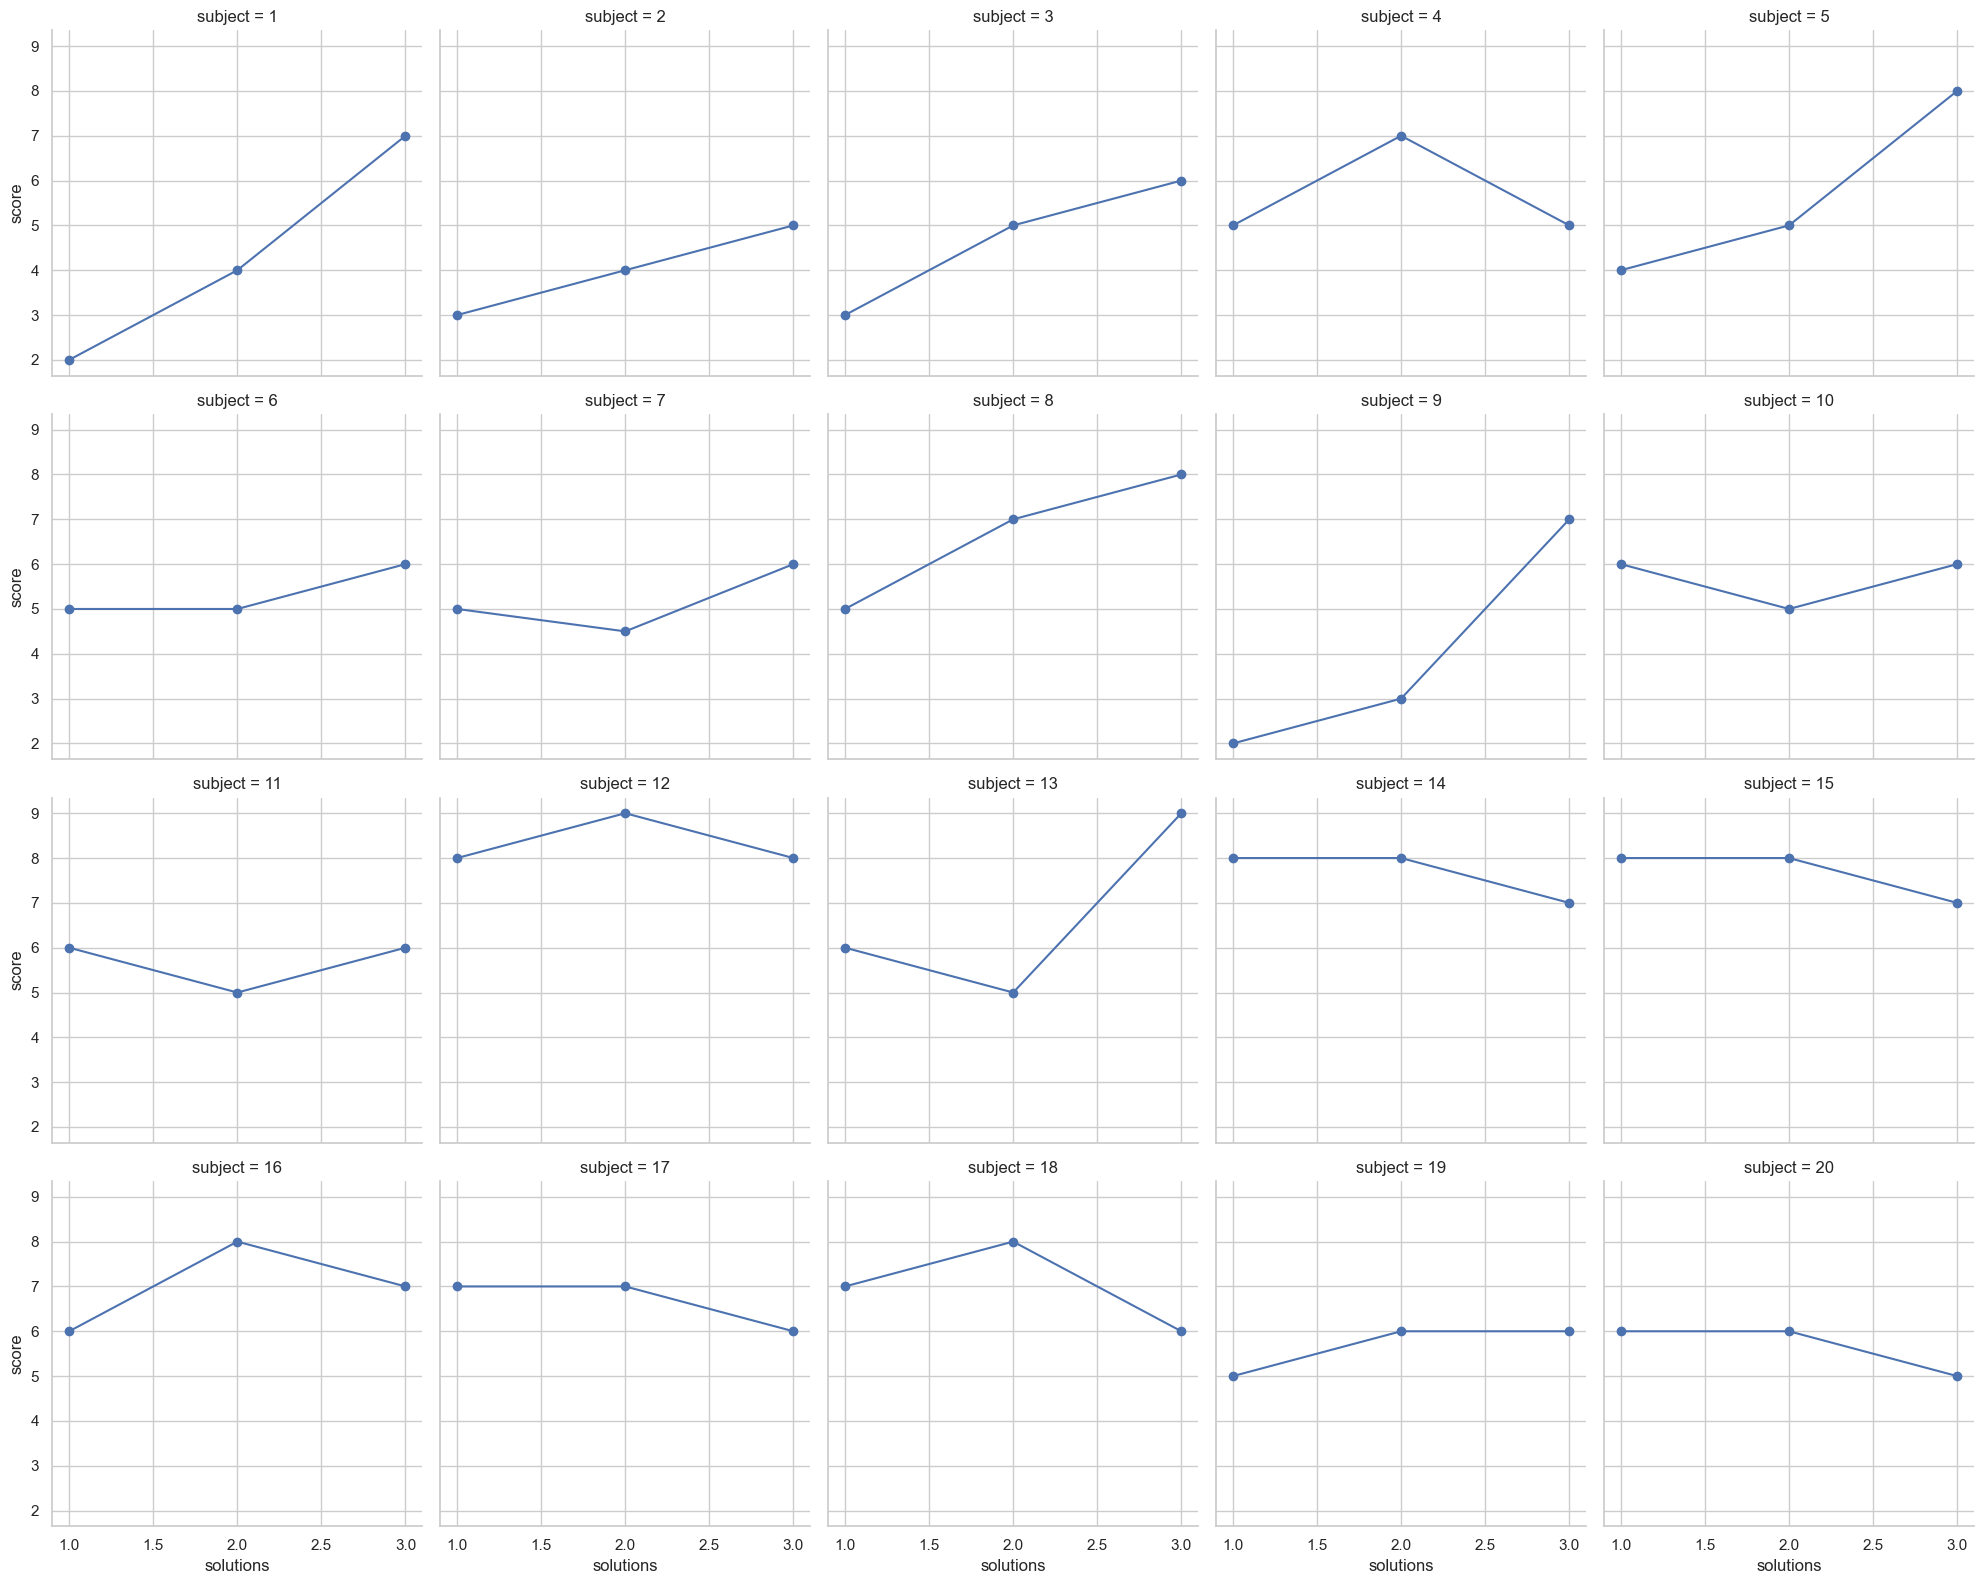

In [ ]:
# FacetGrid with col_wrap - great for many categories
att_df = sns.load_dataset("attention")

att_fg = sns.FacetGrid(
    att_df, 
    col="subject",      # Create one subplot per subject (14 total)
    col_wrap=5,         # Wrap to 5 columns (will create multiple rows)
    height=3
)

att_fg.map(
    plt.plot, 
    "solutions", 
    "score", 
    marker="o",
    linewidth=2,
    markersize=6
)

att_fg.set_axis_labels("Solutions", "Score")
att_fg.set_titles("Subject {col_name}")
plt.suptitle("Attention Experiment: Score per Subject", fontsize=13, y=1.00, fontweight='bold')
plt.tight_layout()
plt.show()